In [2]:
# =================================================
# 1. ИМПОРТ БИБЛИОТЕК И НАСТРОЙКИ
# =================================================
import pandas as pd          # для работы с таблицами
import numpy as np           # для числовых операций
import matplotlib.pyplot as plt   # для графиков
import seaborn as sns        # для красивой статистической визуализации

# Настройки отображения (показывать все столбцы, не скрывать)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)   # показывать 10 строк в head/describe

In [3]:
# =================================================
# 2. ЗАГРУЗКА ДАННЫХ
# =================================================
# Убедитесь, что файл лежит в той же папке, что и ноутбук
df = pd.read_csv('ml_dataset_20k.csv')
print("Данные загружены. Размер таблицы:", df.shape)  # (строк, столбцов)

Данные загружены. Размер таблицы: (5938, 21)


In [4]:
# =================================================
# 3. PANDAS – ОСНОВНЫЕ КОМАНДЫ (часть 1: обзор)
# =================================================

# 3.1. Просмотр первых строк
print("\n--- head() --- первые 5 строк:")
print(df.head())

# 3.2. Информация о DataFrame
print("\n--- info() --- типы данных и количество непустых значений:")
df.info()

# 3.3. Статистическое описание числовых столбцов
print("\n--- describe() --- статистика:")
print(df.describe())

# 3.4. Размер таблицы (shape)
print("\n--- shape --- размер:", df.shape)

# 3.5. Названия столбцов
print("\n--- columns --- список столбцов:")
print(df.columns.tolist())

# 3.6. Проверка пропусков
print("\n--- isnull().sum() --- пропуски по столбцам:")
print(df.isnull().sum())


--- head() --- первые 5 строк:
   incident_id  probability  is_real_incident       last_order_end  \
0        25744           70                 0  0001-01-01T00:00:00   
1        25743            0                 0  0001-01-01T00:00:00   
2        25741           70                 0  0001-01-01T00:00:00   
3        25740           70                 0  0001-01-01T00:00:00   
4        25739            0                 0  0001-01-01T00:00:00   

            after_order_start   gap_minutes  total_after_distance_km  \
0  2025-03-10T01:12:28.299000  1.064619e+09                    1.124   
1  2025-03-10T18:12:55.712000  1.064620e+09                    0.022   
2  2025-03-10T16:36:27.604000  1.064620e+09                    2.635   
3  2025-03-10T12:00:00.595000  1.064620e+09                    5.898   
4  2025-03-10T19:06:51.672000  1.064621e+09                    0.252   

   max_jump_distance_km  mean_speed_kmh  median_speed_kmh  max_speed_kmh  \
0                 0.135            0.0

In [6]:
# =================================================
# 3. PANDAS – ОСНОВНЫЕ КОМАНДЫ (часть 2: выборка и группировка)
# =================================================

# 3.7. Выбор одного столбца
print("\n--- выбор одного столбца (Series) --- первые 5 значений probability:")
print(df['probability'].head())

# 3.8. Выбор нескольких столбцов
print("\n--- выбор нескольких столбцов --- первые 3 строки с incident_id и probability:")
print(df[['incident_id', 'probability']].head(3))

# 3.9. Фильтрация строк по условию
print("\n--- фильтр: строки с is_real_incident == 1 (первые 5):")
print(df[df['is_real_incident'] == 1].head(5))

# 3.10. Группировка и агрегация
print("\n--- groupby: среднее probability по is_real_incident:")
print(df.groupby('is_real_incident')['probability'].mean())

# 3.11. Сортировка
print("\n--- sort_values: топ-5 по probability (убывание):")
print(df.sort_values('probability', ascending=False)[['incident_id', 'probability']].head())

# 3.12. Обработка пропусков (если бы они были)
# df_dropped = df.dropna()          # удалить строки с пропусками
# df_filled = df.fillna(0)          # заполнить пропуски нулями

# 3.13. Сохранение в CSV (закомментировано, чтобы случайно не перезаписать)
# df.to_csv('output.csv', index=False)


--- выбор одного столбца (Series) --- первые 5 значений probability:
0    70
1     0
2    70
3    70
4     0
Name: probability, dtype: int64

--- выбор нескольких столбцов --- первые 3 строки с incident_id и probability:
   incident_id  probability
0        25744           70
1        25743            0
2        25741           70

--- фильтр: строки с is_real_incident == 1 (первые 5):
    incident_id  probability  is_real_incident       last_order_end  \
9         25733           70                 1  0001-01-01T00:00:00   
12        25727            0                 1  0001-01-01T00:00:00   
16        25723            0                 1  0001-01-01T00:00:00   
25        25711           55                 1  0001-01-01T00:00:00   
46        25686           70                 1  0001-01-01T00:00:00   

             after_order_start   gap_minutes  total_after_distance_km  \
9   2025-03-10T16:36:27.604000  1.064620e+09                    1.942   
12  2025-03-10T18:42:21.804000  1.064

In [ ]:
# =================================================
# 4. NUMPY – РАБОТА С МАССИВАМИ
# =================================================

# 4.1. Создание массива из списка
arr = np.array([1, 2, 3, 4, 5])
print("\n--- np.array --- массив:", arr)

# 4.2. Массив из нулей
zeros = np.zeros((3, 2))
print("\n--- np.zeros --- массив 3x2 из нулей:\n", zeros)

# 4.3. Массив из единиц
ones = np.ones((2, 4))
print("\n--- np.ones --- массив 2x4 из единиц:\n", ones)

# 4.4. Случайные числа (нормальное распределение)
X = np.random.randn(100, 5)   # 100 строк, 5 столбцов
print("\n--- np.random.randn --- создана матрица 100x5")

# 4.5. Размерность массива (shape)
print("shape матрицы X:", X.shape)

# 4.6. Статистики по массиву
print("Среднее всей матрицы:", X.mean())
print("Среднее по столбцам (axis=0):", X.mean(axis=0))
print("Стандартное отклонение по столбцам:", X.std(axis=0))

# 4.7. Матричное умножение (@)
w = np.random.randn(5)       # вектор весов
y = X @ w                    # результат (100 чисел)
print("Результат умножения X @ w, форма y:", y.shape)
print(y)

# 4.8. Изменение формы (reshape)
arr_reshaped = arr.reshape(5, 1)   # превращаем вектор в столбец
print("\n--- reshape --- массив arr как столбец:\n", arr_reshaped)

# 4.9. Транспонирование
print("Транспонирование матрицы X, новая форма:", X.T.shape)

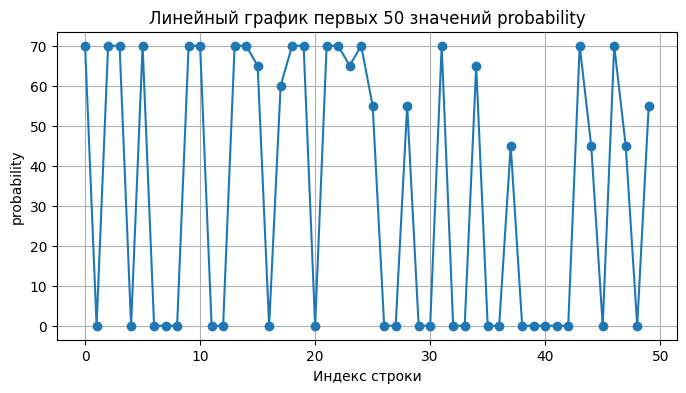

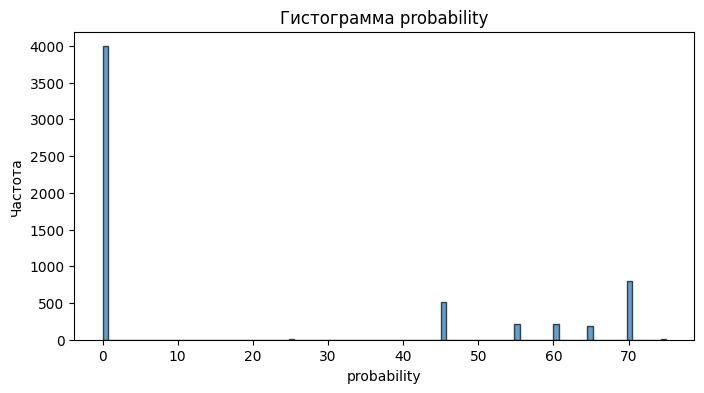

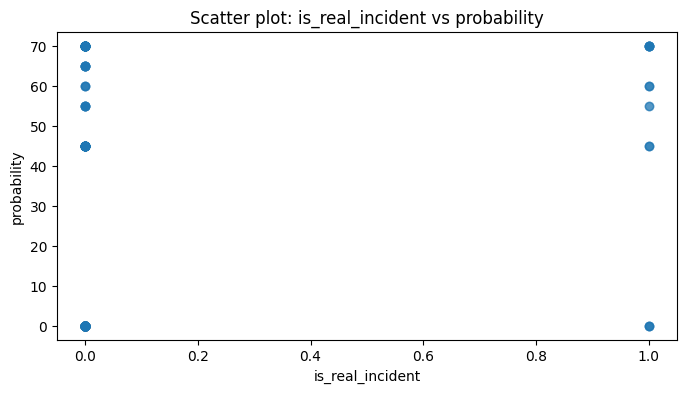

In [15]:
# =================================================
# 5. MATPLOTLIB – БАЗОВАЯ ВИЗУАЛИЗАЦИЯ
# =================================================

# 5.1. Линейный график
plt.figure(figsize=(8,4))
plt.plot(df.index[:50], df['probability'][:50], marker='o', linestyle='-')
plt.title('Линейный график первых 50 значений probability')
plt.xlabel('Индекс строки')
plt.ylabel('probability')
plt.grid(True)
plt.show()

# 5.2. Гистограмма
plt.figure(figsize=(8,4))
plt.hist(df['probability'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Гистограмма probability')
plt.xlabel('probability')
plt.ylabel('Частота')
plt.show()

# 5.3. Диаграмма рассеяния (scatter)
# Выбираем два столбца для примера
if 'target' in df.columns:
    x_col = 'x0'
    y_col = 'target'
else:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    x_col, y_col = numeric_cols[2], numeric_cols[3]

plt.figure(figsize=(8,4))
plt.scatter(df[x_col][:200], df['probability'][:200], alpha=0.5)
plt.title(f'Scatter plot: {x_col} vs probability')
plt.xlabel(x_col)
plt.ylabel('probability')
plt.show()

In [ ]:
# =================================================
# 6. SEABORN – СТАТИСТИЧЕСКАЯ ВИЗУАЛИЗАЦИЯ
# =================================================

# 6.1. Гистограмма с оценкой плотности (kde)
plt.figure(figsize=(8,4))
sns.histplot(df['probability'], bins=30, kde=True)
plt.title('Seaborn: распределение probability')
plt.show()

# 6.2. Тепловая карта корреляций
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций (Seaborn)')
plt.show()

In [17]:
# =================================================
# 7. ДОПОЛНИТЕЛЬНЫЕ ПОЛЕЗНЫЕ КОМАНДЫ
# =================================================

# 7.1. Уникальные значения в столбце
print("\n--- unique() --- уникальные значения is_real_incident:")
print(df['is_real_incident'].unique())

# 7.2. Количество уникальных
print("Количество уникальных в is_real_incident:", df['is_real_incident'].nunique())

# 7.3. Срез по индексу (iloc) – выбор строк по позициям
print("\n--- iloc[10:15] --- строки 10-14 (первые три столбца):")
print(df.iloc[10:15, :3])

# 7.4. Срез по метке (loc) – выбор по условию
print("\n--- loc[df['probability'] > 80] --- строки с probability > 80 (первые 5):")
print(df.loc[df['probability'] > 0, ['incident_id', 'probability']].head())

print("\n🎉 Готово! Все основные команды продемонстрированы. Обратите внимание на графики выше.")


--- unique() --- уникальные значения is_real_incident:
[0 1]
Количество уникальных в is_real_incident: 2

--- iloc[10:15] --- строки 10-14 (первые три столбца):
    incident_id  probability  is_real_incident
10        25729           70                 0
11        25728            0                 0
12        25727            0                 1
13        25726           70                 0
14        25725           70                 0

--- loc[df['probability'] > 80] --- строки с probability > 80 (первые 5):
   incident_id  probability
0        25744           70
2        25741           70
3        25740           70
5        25738           70
9        25733           70

🎉 Готово! Все основные команды продемонстрированы. Обратите внимание на графики выше.
